[*********************100%***********************]  1 of 1 completed


--- RESULTADOS DE LA SIMULACIÓN ---
Estrategia Única (Lump Sum):
  Valor Final Promedio: $5760.70
  Desviación Estándar:  $1099.49
  Prob. de Pérdida:     25.70%

Estrategia Periódica (DCA):
  Valor Final Promedio: $5377.02
  Desviación Estándar:  $615.09
  Prob. de Pérdida:     27.93%


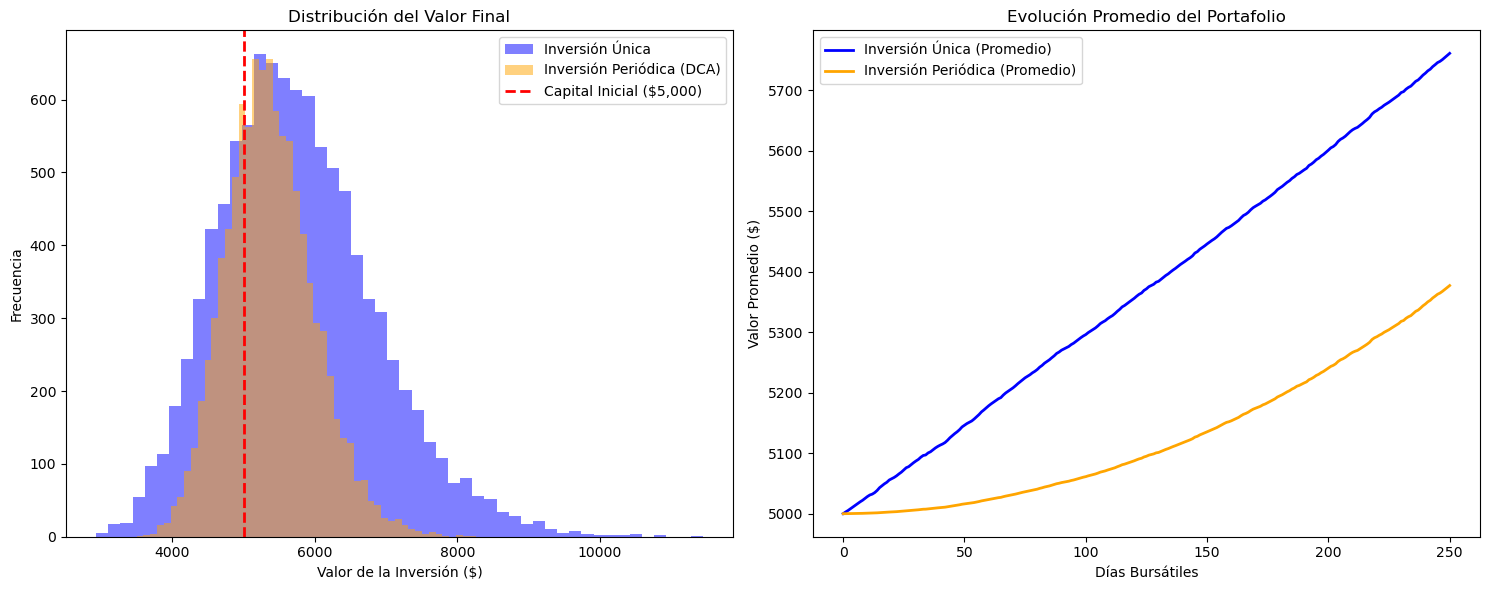

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
tickers = ["V"]
end = dt.datetime.today()
start = end - dt.timedelta(days=365*3)
data = yf.download(tickers, start=start, end=end)["Close"]
returns = data.pct_change().dropna()
mu = returns.mean().item()
sigma = returns.std().item()
S0 = data.iloc[-1].item() 
n_sim = 10000
inversion_total = 5000
inversion_semanal = 100
semanas = int(inversion_total / inversion_semanal)
n_days = semanas * 5 
price_paths = np.zeros((n_days + 1, n_sim))
price_paths[0] = S0
Z = np.random.normal(0, 1, size=(n_days, n_sim))
daily_drift = mu - 0.5 * sigma**2
for t in range(1, n_days + 1):
    price_paths[t] = price_paths[t-1] * np.exp(daily_drift + sigma * Z[t-1])

shares_ls = inversion_total / S0
val_ls = shares_ls * price_paths
final_ls = val_ls[-1]
val_dca = np.zeros((n_days + 1, n_sim))
shares_dca = np.zeros(n_sim)
cash = inversion_total

for t in range(n_days + 1):
    if t % 5 == 0 and cash > 0:
        shares_bought = inversion_semanal / price_paths[t]
        shares_dca += shares_bought
        cash -= inversion_semanal
    val_dca[t] = shares_dca * price_paths[t] + cash
    
final_dca = val_dca[-1]

media_ls = np.mean(final_ls)
std_ls = np.std(final_ls)
prob_perdida_ls = np.mean(final_ls < inversion_total)

media_dca = np.mean(final_dca)
std_dca = np.std(final_dca)
prob_perdida_dca = np.mean(final_dca < inversion_total)
print("--- RESULTADOS DE LA SIMULACIÓN ---")
print(f"Estrategia Única (Lump Sum):")
print(f"  Valor Final Promedio: ${media_ls}")
print(f"  Desviación Estándar:  ${std_ls}")
print(f"  Prob. de Pérdida:     {prob_perdida_ls}\n")
print(f"Estrategia Periódica (DCA):")
print(f"  Valor Final Promedio: ${media_dca}")
print(f"  Desviación Estándar:  ${std_dca}")
print(f"  Prob. de Pérdida:     {prob_perdida_dca}")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].hist(final_ls, bins=50, alpha=0.5, label='Inversión Única', color='blue')
axes[0].hist(final_dca, bins=50, alpha=0.5, label='Inversión Periódica (DCA)', color='orange')
axes[0].axvline(inversion_total, color='red', linestyle='dashed', linewidth=2, label='Capital Inicial ($5,000)')
axes[0].set_title('Distribución del Valor Final')
axes[0].set_xlabel('Valor de la Inversión ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
avg_path_ls = np.mean(val_ls, axis=1)
avg_path_dca = np.mean(val_dca, axis=1)

axes[1].plot(avg_path_ls, label='Inversión Única (Promedio)', color='blue', linewidth=2)
axes[1].plot(avg_path_dca, label='Inversión Periódica (Promedio)', color='orange', linewidth=2)
axes[1].set_title('Evolución Promedio del Portafolio')
axes[1].set_xlabel('Días Bursátiles')
axes[1].set_ylabel('Valor Promedio ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

**¿En qué condiciones es más ventajosa la inversión periódica?**

La inversion periodica es mas solida, no tiene tanto riesgo, se ve que esta mas centrada en $S0$, tambien es mas ventajosa si uno no tiene de golpe 5000 dolares que ese es el caso para la gran mayoria

**¿Cuándo es preferible la inversión en un solo momento?**

Cuando esta el capital inicial y es un perfil un poco mas preferente al riesgo o adverso a este